Total rows with best_mass>0: 739
Rows with reject_null=True:  477

=== Derived IMF Slopes ===
All stars:          α = 1.23
Reject-null only:   α = 1.37


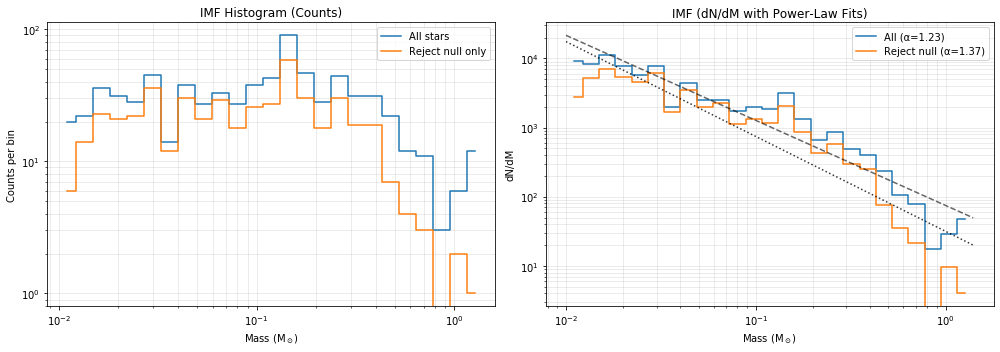

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- Load fit results ---
csv_path = "fit_results_jwst_hstall.csv"
df = pd.read_csv(csv_path)

# Basic sanity filtering
df = df.dropna(subset=["best_mass"])
df = df[df["best_mass"] > 0].copy()

# "Statistically significant" = reject null hypothesis
df["reject_null"] = df[["mass_min","mass_max","AV_min","AV_max"]].notnull().all(axis=1)

m_all = df["best_mass"].values
m_sig = df.loc[df["reject_null"], "best_mass"].values

print(f"Total rows with best_mass>0: {len(m_all)}")
print(f"Rows with reject_null=True:  {len(m_sig)}")

# --- IMF binning (log-spaced) ---
m_min = max(0.01, np.nanmin(m_all))
m_max = np.nanmax(m_all)
nbins = 25

bins = np.logspace(np.log10(m_min), np.log10(m_max), nbins + 1)

# --- Histograms ---
N_all, edges = np.histogram(m_all, bins=bins)
N_sig, _     = np.histogram(m_sig, bins=bins)

bin_centers = np.sqrt(edges[:-1] * edges[1:])
bin_widths  = edges[1:] - edges[:-1]

# dN/dM
dndm_all = N_all / bin_widths
dndm_sig = N_sig / bin_widths

# ---------------------------------------------------
# FIT IMF SLOPES (log–log linear regression)
# ---------------------------------------------------
def fit_imf_slope(mass, dndm):
    mask = (dndm > 0) & np.isfinite(dndm)
    logM = np.log10(mass[mask])
    logN = np.log10(dndm[mask])

    slope, intercept = np.polyfit(logM, logN, 1)
    alpha = -slope   # IMF convention

    return alpha, slope, intercept

alpha_all, slope_all, intercept_all = fit_imf_slope(bin_centers, dndm_all)
alpha_sig, slope_sig, intercept_sig = fit_imf_slope(bin_centers, dndm_sig)

print("\n=== Derived IMF Slopes ===")
print(f"All stars:          α = {alpha_all:.2f}")
print(f"Reject-null only:   α = {alpha_sig:.2f}")

# ---------------------------------------------------
# PLOTTING
# ---------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Counts ---
axes[0].step(bin_centers, N_all, where="mid", label="All stars")
axes[0].step(bin_centers, N_sig, where="mid", label="Reject null only")
axes[0].set_xscale("log")
axes[0].set_yscale("log")
axes[0].set_xlabel("Mass (M$_\\odot$)")
axes[0].set_ylabel("Counts per bin")
axes[0].set_title("IMF Histogram (Counts)")
axes[0].grid(True, which="both", alpha=0.3)
axes[0].legend()

# --- dN/dM with fitted slopes ---
axes[1].step(bin_centers, dndm_all, where="mid", label=f"All (α={alpha_all:.2f})")
axes[1].step(bin_centers, dndm_sig, where="mid", label=f"Reject null (α={alpha_sig:.2f})")

# Overlay fitted power laws
M_fit = np.linspace(m_min, m_max, 200)
axes[1].plot(
    M_fit,
    10**(intercept_all + slope_all * np.log10(M_fit)),
    "k--",
    alpha=0.6
)

axes[1].plot(
    M_fit,
    10**(intercept_sig + slope_sig * np.log10(M_fit)),
    "k:",
    alpha=0.8
)

axes[1].set_xscale("log")
axes[1].set_yscale("log")
axes[1].set_xlabel("Mass (M$_\\odot$)")
axes[1].set_ylabel("dN/dM")
axes[1].set_title("IMF (dN/dM with Power-Law Fits)")
axes[1].grid(True, which="both", alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()